# The agent loop, in code — live demo

Companion to the lecture **The agent loop, in code**. We build *one* tool-using
agent and run it on **three stacks**, watching the same loop each time:

> **Call the model → it asks for a tool → you run the tool → hand back the result → repeat until it stops.**

| Deck part | Notebook section |
|---|---|
| 1 — The loop | §1 Tools (local & deterministic) |
| 2 — Raw Anthropic | §2 The loop on the Anthropic SDK + trajectory printer |
| 2 — Raw OpenAI | §3 The same agent on the OpenAI SDK |
| 3 — LangChain / LangGraph | §4 LangChain (`AgentExecutor`, `create_agent`) · §5 `StateGraph` · §6 prebuilt |
| 4 — In practice | §7 A good error message vs a bad one |

**Key design choice:** the three tools (`get_weather`, `calculator`,
`web_search`) run *in this notebook* and return canned/deterministic results.
There is **no magic and no hidden network** — the only thing that reaches out is
the LLM. So every step you see printed is the agent deciding what to do next.

## 0. Setup

Install the SDKs (uncomment if needed), then read API keys from the environment.
Everything degrades gracefully: if a key or package is missing, that section
prints a note and skips instead of crashing.

In [1]:
from dotenv import load_dotenv
load_dotenv("/home/amir/.env")

True

In [2]:
# !pip install -q anthropic openai langgraph langchain-anthropic langchain-openai langchain-core
import os, json, difflib

import anthropic
from openai import OpenAI


In [3]:
ANTHROPIC_MODEL = "claude-opus-4-8"

# Anthropic client (the star of the demo)
aclient = anthropic.Anthropic()
print("Anthropic client ready — model:", ANTHROPIC_MODEL)

Anthropic client ready — model: claude-opus-4-8


In [4]:
OPENAI_MODEL    = "gpt-4o"

# OpenAI client — to show the loop is provider-independent
oclient = OpenAI()
print("OpenAI client ready — model:", OPENAI_MODEL)

OpenAI client ready — model: gpt-4o


## 1. The tools — local, deterministic, and the only thing that matters

A tool is just a Python function plus a schema. These three implementations are
shared by **all three stacks** below — only the wrapper around them changes.

Note the **error path** in `get_weather`: an unknown city returns a *readable*
error with a suggestion. That single design decision is what lets the agent
recover instead of looping (we prove it in §6).

In [5]:
# A tiny "world" so the demo is fully deterministic --------------------------
WEATHER = {
    "paris": "18°C, light rain",
    "tel aviv": "29°C, sunny",
    "tokyo": "23°C, humid, clear",
    "london": "15°C, overcast",
    "new york": "21°C, partly cloudy",
    "los angeles": "27°C, sunny",
    "berlin": "17°C, windy",
}

SEARCH = {
    "olympic": "The 2028 Summer Olympics will be held in Los Angeles, USA.",
    "world cup": "The 2026 FIFA World Cup will be co-hosted by the USA, Canada and Mexico.",
    "capital of france": "The capital of France is Paris.",
    "tallest mountain": "The tallest mountain on Earth is Mount Everest (8,849 m).",
}

def get_weather(city: str) -> str:
    '''Look up current weather for a city. Unknown city → readable error.'''
    key = city.strip().lower()
    if key in WEATHER:
        return f"{WEATHER[key]} in {city.strip()}."
    near = difflib.get_close_matches(key, WEATHER, n=1)
    hint = f" Did you mean '{near[0].title()}'?" if near else ""
    return (f"Error: no weather station for '{city}'.{hint} "
            f"Known cities: {', '.join(c.title() for c in WEATHER)}.")

def calculator(expression: str) -> str:
    '''Evaluate a basic arithmetic expression. Digits and + - * / ( ) . only.'''
    import re
    if not re.fullmatch(r"[0-9+\-*/(). %]+", expression or ""):
        return f"Error: '{expression}' is not a plain arithmetic expression."
    try:
        return str(eval(expression, {"__builtins__": {}}, {}))  # sandboxed: no builtins
    except Exception as e:
        return f"Error evaluating '{expression}': {e}"

def web_search(query: str) -> str:
    '''Search a small canned knowledge base; returns the best matching fact.'''
    q = (query or "").lower()
    for keyword, fact in SEARCH.items():
        if keyword in q:
            return fact
    return f"No results found for '{query}'."

# One dispatch table the loop will call, by tool name ------------------------
TOOL_FUNCS = {"get_weather": get_weather,
              "calculator": calculator,
              "web_search": web_search}

# quick offline sanity check (no LLM involved) -------------------------------
print(get_weather("Tel Aviv"))
print(get_weather("Prais"))          # the recoverable error
print(calculator("15 * (3 + 1)"))
print(web_search("where are the next olympics held"))

29°C, sunny in Tel Aviv.
Error: no weather station for 'Prais'. Did you mean 'Paris'? Known cities: Paris, Tel Aviv, Tokyo, London, New York, Los Angeles, Berlin.
60
The 2028 Summer Olympics will be held in Los Angeles, USA.


## 2. The loop on the raw Anthropic SDK

First the **tool schemas** — name, description (the *trigger* the model reads),
and a JSON schema for the arguments. Then the loop itself, with a trajectory
printer so we can watch each turn.

In [6]:
TOOLS_ANTHROPIC = [
    {
        "name": "get_weather",
        "description": "Get the current weather for a city. "
                       "Call this whenever the user asks about weather.",
        "input_schema": {
            "type": "object",
            "properties": {"city": {"type": "string", "description": "City name"}},
            "required": ["city"],
        },
    },
    {
        "name": "calculator",
        "description": "Evaluate a basic arithmetic expression "
                       "(e.g. '15 * (3 + 1)'). Use for any arithmetic.",
        "input_schema": {
            "type": "object",
            "properties": {"expression": {"type": "string"}},
            "required": ["expression"],
        },
    },
    {
        "name": "web_search",
        "description": "Search the web for a fact you don't already know "
                       "(events, places, dates). Returns a short text snippet.",
        "input_schema": {
            "type": "object",
            "properties": {"query": {"type": "string"}},
            "required": ["query"],
        },
    },
]

### First, the five steps by hand (slide 8)

Before we hide the loop inside a function, let's run **one tool call manually** —
one cell per step — exactly as in the deck's sequence diagram:

1. **Tool definitions + messages** → send the question *and* the tool catalog
2. **Tool call** ← the model asks for a tool instead of answering
3. **Execute** — *our* code runs the function
4. **Results** → append the output and **resend the whole conversation**
5. **Final response** ← the model answers in words

We use the figure's own example, *"What's the weather in Paris?"* — a single tool,
a single round trip. Nothing loops yet; **we are the loop.**

In [45]:
# STEP 1 — send the tool definitions + the user message to the model
messages = [{"role": "user", "content": "What's the weather in Paris?"}]

resp = aclient.messages.create(
    model=ANTHROPIC_MODEL, max_tokens=1024,
    tools=TOOLS_ANTHROPIC, messages=messages,
)

# The model did NOT answer in words — it asked to use a tool:
print("stop_reason:", resp.stop_reason)      # → 'tool_use'
resp.content                                  # a list containing a tool_use block

stop_reason: tool_use


[TextBlock(citations=None, text="I'll check the weather in Paris for you.", type='text'),
 ToolUseBlock(id='toolu_019uSi3EbtnWWNYhBteyB7sE', caller=DirectCaller(type='direct'), input={'city': 'Paris'}, name='get_weather', type='tool_use')]

In [46]:
# STEP 2 — read the tool call the model returned (name + arguments + id)
tool_call = next(b for b in resp.content if b.type == "tool_use")

print("tool name :", tool_call.name)          # → get_weather
print("arguments :", tool_call.input)         # → {'city': 'Paris'}
print("call id   :", tool_call.id)            # we must echo this back in step 4

tool name : get_weather
arguments : {'city': 'Paris'}
call id   : toolu_019uSi3EbtnWWNYhBteyB7sE


In [47]:
# STEP 3 — WE execute the function, in our own code (the model never runs it)
result = TOOL_FUNCS[tool_call.name](**tool_call.input)
print("tool result:", result)

tool result: 18°C, light rain in Paris.


In [48]:
# STEP 4 — append the model's turn AND our result, then resend EVERYTHING.
# The API is stateless: this messages list is the only memory of the conversation.
messages.append({"role": "assistant", "content": resp.content})       # what the model asked
messages.append({"role": "user", "content": [{                        # what the tool returned
    "type": "tool_result",
    "tool_use_id": tool_call.id,        # ← links the result to the call from step 2
    "content": result,
}]})

print(f"the conversation is now {len(messages)} messages:")
print("  1.", messages[0]["role"], "→ the question (text)")
print("  2.", messages[1]["role"], "→ the model's tool_use request")
print("  3.", messages[2]["role"], "→ our tool_result")

the conversation is now 3 messages:
  1. user → the question (text)
  2. assistant → the model's tool_use request
  3. user → our tool_result


In [49]:
# STEP 5 — resend the whole conversation; now the model has the result and answers
resp2 = aclient.messages.create(
    model=ANTHROPIC_MODEL, max_tokens=1024,
    tools=TOOLS_ANTHROPIC, messages=messages,
)

print("stop_reason:", resp2.stop_reason)      # → 'end_turn' (no more tools — it's done)
final = "".join(b.text for b in resp2.content if b.type == "text")
print("\n💬", final)

stop_reason: end_turn

💬 The weather in Paris is currently **18°C with light rain**. You might want to bring an umbrella if you're heading out! ☔


### From five steps to a loop

That's the entire protocol. Two things to notice:

- **Steps 2–4 are the repeatable unit.** Here the model finished after one tool
  call (step 5 was `end_turn`). But if step 5 had itself been another `tool_use`,
  we'd just do steps 2–4 again — and again — until the model stops asking.
- **The conversation is the state.** Every turn we *append* to and *resend* the
  full `messages` list; the API remembers nothing on its own.

Wrapping *"repeat steps 2–4 until `stop_reason != 'tool_use'`"* in a `while` loop
is **exactly** the `run_agent_anthropic` function below.

In [50]:
def run_agent_anthropic(user_msg, model=ANTHROPIC_MODEL, max_turns=8, verbose=True):
    '''The entire agent: model -> tool request -> run tool -> feed back -> repeat.'''

    messages = [{"role": "user", "content": user_msg}]
    if verbose: print(f"🧑  {user_msg}\n" + "─" * 70)

    for turn in range(1, max_turns + 1):
        resp = aclient.messages.create(
            model=model, max_tokens=1024,
            tools=TOOLS_ANTHROPIC, messages=messages,
        )
        messages.append({"role": "assistant", "content": resp.content})

        # show any text the model wrote this turn
        text = "".join(b.text for b in resp.content if b.type == "text").strip()
        if verbose and text:
            print(f"🤖  {text}")

        if resp.stop_reason != "tool_use":          # ← no tool call ⇒ final answer
            if verbose: print("─" * 70 + f"\n✅  {text}")
            return text

        # execute every tool the model asked for, in YOUR code
        results = []
        for b in resp.content:
            if b.type == "tool_use":
                out = TOOL_FUNCS[b.name](**b.input)
                if verbose:
                    print(f"   🔧 turn {turn}: {b.name}({b.input}) ")
                    print(f"      ↩  {out}")
                results.append({"type": "tool_result",
                                "tool_use_id": b.id, "content": out})
        messages.append({"role": "user", "content": results})

    return "⚠️ hit max_turns without finishing"

### Demo A — one tool, one turn

The simplest trajectory: the model calls `get_weather`, reads the result, answers.

In [51]:
run_agent_anthropic("What's the weather like in Tel Aviv right now?")

🧑  What's the weather like in Tel Aviv right now?
──────────────────────────────────────────────────────────────────────
🤖  I'll check the current weather in Tel Aviv for you.
   🔧 turn 1: get_weather({'city': 'Tel Aviv'}) 
      ↩  29°C, sunny in Tel Aviv.
🤖  Right now in Tel Aviv it's **29°C and sunny**. ☀️ A warm, clear day—great weather to be out and about! Just remember to stay hydrated and grab some sunscreen if you'll be spending time outdoors.
──────────────────────────────────────────────────────────────────────
✅  Right now in Tel Aviv it's **29°C and sunny**. ☀️ A warm, clear day—great weather to be out and about! Just remember to stay hydrated and grab some sunscreen if you'll be spending time outdoors.


"Right now in Tel Aviv it's **29°C and sunny**. ☀️ A warm, clear day—great weather to be out and about! Just remember to stay hydrated and grab some sunscreen if you'll be spending time outdoors."

### Demo B — multi-step chaining

The model **can't** answer directly, so it chains tools: `web_search` to find
*where* the next Olympics are, then `get_weather` for that city. The number of
steps is the model's decision, not ours — this is what makes it an *agent*.

In [ ]:
run_agent_anthropic("What's the weather like where the next Summer Olympics will be held?")

### Demo C — two tools in one turn

Ask for two unrelated things; watch the model request **both** tools in a single
turn, then combine the results.

In [17]:
run_agent_anthropic("What's 18 * 7.5, and what's the weather in Tokyo?")

🧑  What's 18 * 7.5, and what's the weather in Tokyo?
──────────────────────────────────────────────────────────────────────
🤖  I'll calculate that and check the weather for you.
   🔧 turn 1: calculator({'expression': '18 * 7.5'}) 
      ↩  135.0
   🔧 turn 1: get_weather({'city': 'Tokyo'}) 
      ↩  23°C, humid, clear in Tokyo.
🤖  - **18 × 7.5 = 135**
- **Tokyo weather:** 23°C, humid, and clear.
──────────────────────────────────────────────────────────────────────
✅  - **18 × 7.5 = 135**
- **Tokyo weather:** 23°C, humid, and clear.


'- **18 × 7.5 = 135**\n- **Tokyo weather:** 23°C, humid, and clear.'

## 3. The same agent on the raw OpenAI SDK

Identical loop. Only the **field names** change: schema lives under
`function.parameters`, the request is `message.tool_calls`, results go back as a
`role: "tool"` message, and arguments arrive as a **JSON string** to parse.
Same `TOOL_FUNCS`, same behaviour.

In [18]:
TOOLS_OPENAI = [{
    "type": "function",
    "function": {
        "name": t["name"],
        "description": t["description"],
        "parameters": t["input_schema"],   # OpenAI calls the schema "parameters"
    },
} for t in TOOLS_ANTHROPIC]                 # ← literally the same tools, re-wrapped


def run_agent_openai(user_msg, model=OPENAI_MODEL, max_turns=8, verbose=True):
    messages = [{"role": "user", "content": user_msg}]
    if verbose: print(f"🧑  {user_msg}\n" + "─" * 70)

    for turn in range(1, max_turns + 1):
        resp = oclient.chat.completions.create(
            model=model, tools=TOOLS_OPENAI, messages=messages,
        )
        msg = resp.choices[0].message
        messages.append(msg)

        if verbose and msg.content:
            print(f"🤖  {msg.content}")

        if not msg.tool_calls:                       # ← no tool call ⇒ final answer
            if verbose: print("─" * 70 + f"\n✅  {msg.content}")
            return msg.content

        for call in msg.tool_calls:
            args = json.loads(call.function.arguments)   # ← arguments are a string
            out = TOOL_FUNCS[call.function.name](**args)
            if verbose:
                print(f"   🔧 turn {turn}: {call.function.name}({args}) ")
                print(f"      ↩  {out}")
            messages.append({"role": "tool", "tool_call_id": call.id, "content": out})

    return "⚠️ hit max_turns without finishing"

In [19]:
run_agent_openai("What's the weather like where the next Summer Olympics will be held?")


🧑  What's the weather like where the next Summer Olympics will be held?
──────────────────────────────────────────────────────────────────────
   🔧 turn 1: web_search({'query': 'location of the next Summer Olympics'}) 
      ↩  The 2028 Summer Olympics will be held in Los Angeles, USA.
   🔧 turn 1: get_weather({'city': 'Paris'}) 
      ↩  18°C, light rain in Paris.
🤖  The next Summer Olympics will be held in Los Angeles, USA, in 2028. Currently, in Paris, the weather is 18°C with light rain.
──────────────────────────────────────────────────────────────────────
✅  The next Summer Olympics will be held in Los Angeles, USA, in 2028. Currently, in Paris, the weather is 18°C with light rain.


'The next Summer Olympics will be held in Los Angeles, USA, in 2028. Currently, in Paris, the weather is 18°C with light rain.'

## 4. The LangChain agent — `AgentExecutor` and `create_agent`

§2–§3 hand-wrote the loop; §5–§6 will express it as a LangGraph graph. In between
sits **LangChain's own agent runner** — the loop wrapped in a helper, no graph to
wire up. LangChain has had two generations:

- **`AgentExecutor`** *(classic)* — the original agent loop. In LangChain **v1** it
  moved to a separate package: `pip install langchain-classic`,
  then `from langchain_classic.agents import AgentExecutor, create_tool_calling_agent`.
- **`create_agent`** *(current, v1)* — the modern one-liner: `from langchain.agents import create_agent`.
  It's built on LangGraph and **replaces** `langgraph.prebuilt.create_react_agent` (which §6 still shows).

Same three tools, same question — both run the loop for you.

### How `@tool` builds the schema

We never wrote a schema for the LangChain path — where does it come from? `@tool`
(same as `tool(fn)`) **derives it from the function**: name → tool name,
docstring → description, type hints → the argument schema.

In [7]:
# (a) CLASSIC — AgentExecutor. On LangChain v1 it lives in langchain-classic.
from langchain_classic.agents import AgentExecutor, create_tool_calling_agent
from langchain_core.prompts import ChatPromptTemplate
from langchain_anthropic import ChatAnthropic
from langchain_core.tools import tool

lc_tools = [tool(get_weather), tool(calculator), tool(web_search)]

prompt = ChatPromptTemplate.from_messages([
    ("system", "You are a helpful assistant. Use tools when they help."),
    ("human", "{input}"),
    ("placeholder", "{agent_scratchpad}"),   # running tool calls + results = the state
])
agent = create_tool_calling_agent(ChatAnthropic(model=ANTHROPIC_MODEL), lc_tools, prompt)
executor = AgentExecutor(agent=agent, tools=lc_tools, verbose=True)   # verbose prints the loop

out = executor.invoke({"input": "What's the weather where the next Summer Olympics will be held?"})
print("\n✅", out["output"])



> Entering new AgentExecutor chain...

Invoking: `web_search` with `{'query': 'next Summer Olympics host city'}`
responded: [{'text': "I'll find out where the next Summer Olympics will be held, then check the weather there.", 'type': 'text', 'index': 0}, {'id': 'toolu_01JJ8zbEwoZt7t7XvsD8NXSq', 'caller': {'type': 'direct'}, 'input': {}, 'name': 'web_search', 'type': 'tool_use', 'index': 1, 'partial_json': '{"query": "next Summer Olympics host city"}'}]

The 2028 Summer Olympics will be held in Los Angeles, USA.
Invoking: `get_weather` with `{'city': 'Los Angeles'}`
responded: [{'text': 'The next Summer Olympics will be in Los Angeles. Let me check the weather there.', 'type': 'text', 'index': 0}, {'id': 'toolu_01TXkVND7egCEQ9v8uSwaJHu', 'caller': {'type': 'direct'}, 'input': {}, 'name': 'get_weather', 'type': 'tool_use', 'index': 1, 'partial_json': '{"city": "Los Angeles"}'}]

27°C, sunny in Los Angeles.[{'text': 'The next Summer Olympics will be held in **Los Angeles, USA** (in 2028

In [57]:
from langchain_core.tools import tool
import json

@tool
def get_city_weather(city: str, units: str = "metric") -> str:
    '''Get the current weather for a city.'''    # docstring → description
    ...                                           # body is irrelevant to the schema

# `get_city_weather` is now a tool object with an auto-derived schema:
print("name       :", get_city_weather.name)           # ← function name
print("description:", get_city_weather.description)     # ← docstring
print("\nargs schema, built from the type hints (city required, units optional):")
print(json.dumps(get_city_weather.args_schema.model_json_schema(), indent=2))

# …and it converts to the exact shape we hand-wrote for Anthropic in §2:
from langchain_anthropic import convert_to_anthropic_tool
print("\nas an Anthropic tool (compare to TOOLS_ANTHROPIC in §2):")
print(json.dumps(convert_to_anthropic_tool(get_city_weather), indent=2))

name       : get_city_weather
description: Get the current weather for a city.

args schema, built from the type hints (city required, units optional):
{
  "description": "Get the current weather for a city.",
  "properties": {
    "city": {
      "title": "City",
      "type": "string"
    },
    "units": {
      "default": "metric",
      "title": "Units",
      "type": "string"
    }
  },
  "required": [
    "city"
  ],
  "title": "get_city_weather",
  "type": "object"
}

as an Anthropic tool (compare to TOOLS_ANTHROPIC in §2):
{
  "name": "get_city_weather",
  "input_schema": {
    "properties": {
      "city": {
        "type": "string"
      },
      "units": {
        "default": "metric",
        "type": "string"
      }
    },
    "required": [
      "city"
    ],
    "type": "object"
  },
  "description": "Get the current weather for a city."
}


### The current LangChain prebuilt — `create_agent`

`create_agent` is the v1 replacement. It returns a LangGraph agent, so you invoke
it with a **`messages`** list (just like §5–§6) and read the last message —
note that's a different shape from `AgentExecutor`'s `{"input": ...}` → `["output"]`.

In [ ]:
# (b) CURRENT — create_agent (LangChain v1, built on LangGraph)
from langchain.agents import create_agent
from langchain_anthropic import ChatAnthropic
from langchain_core.tools import tool

lc_tools = [tool(get_weather), tool(calculator), tool(web_search)]

agent = create_agent(
    ChatAnthropic(model=ANTHROPIC_MODEL),       # or model="anthropic:claude-opus-4-8"
    tools=lc_tools,
    system_prompt="You are a helpful assistant. Use tools when they help.",
)

result = agent.invoke(
    {"messages": [{"role": "user",
                    "content": "What's the weather where the next Summer Olympics will be held?"}]})
print("✅", result["messages"][-1].content)
print("ℹ️ full result object:", json.dumps(result, default=str, indent=2))


✅ The next Summer Olympics will be held in **Los Angeles, USA (2028)**, and the weather there right now is **27°C and sunny**. ☀️
ℹ️ full result object: {
  "messages": [
    "content=\"What's the weather where the next Summer Olympics will be held?\" additional_kwargs={} response_metadata={} id='0ca3a1de-491b-4e3c-a4d2-8b122fa186e3'",
    "content=[{'text': \"I'll find out where the next Summer Olympics will be held, then check the weather there.\", 'type': 'text'}, {'id': 'toolu_01TVuw1p3PkeJ88YCh1Pk4Xq', 'caller': {'type': 'direct'}, 'input': {'query': 'next Summer Olympics host city'}, 'name': 'web_search', 'type': 'tool_use'}] additional_kwargs={} response_metadata={'id': 'msg_0181wPg5rqGL8WBsqkEZvcpQ', 'container': None, 'model': 'claude-opus-4-8', 'stop_details': None, 'stop_reason': 'tool_use', 'stop_sequence': None, 'usage': {'cache_creation': {'ephemeral_1h_input_tokens': 0, 'ephemeral_5m_input_tokens': 0}, 'cache_creation_input_tokens': 0, 'cache_read_input_tokens': 0, 'infe

In [14]:
agent_stream = agent.stream(
    {"messages": [{"role": "user", "content": "What's the weather where the next Summer Olympics will be held?"}]},
    stream_mode="values",
)   

for step in agent_stream:
    step["messages"][-1].pretty_print()

================================ Human Message =================================

What's the weather where the next Summer Olympics will be held?
================================== Ai Message ==================================

[{'text': "I'll first find out where the next Summer Olympics will be held, then check the weather there.", 'type': 'text'}, {'id': 'toolu_01EJkbPbhomrAMZ2rrZLGohR', 'caller': {'type': 'direct'}, 'input': {'query': 'next Summer Olympics host city'}, 'name': 'web_search', 'type': 'tool_use'}]
Tool Calls:
  web_search (toolu_01EJkbPbhomrAMZ2rrZLGohR)
 Call ID: toolu_01EJkbPbhomrAMZ2rrZLGohR
  Args:
    query: next Summer Olympics host city
================================= Tool Message =================================
Name: web_search

The 2028 Summer Olympics will be held in Los Angeles, USA.
================================== Ai Message ==================================

[{'text': 'The next Summer Olympics will be in Los Angeles. Let me check the weather there

> Both `AgentExecutor` and `create_agent` **hide** the loop. Next we open it up:
> §5 wires the same loop as an explicit LangGraph `StateGraph`, and §6 is
> LangGraph's own prebuilt one-liner — what `create_agent` is built on.

## 5. The same agent as a LangGraph `StateGraph`

Now the loop becomes the **structure of a graph**: an `agent` node that calls the
model, a `tools` node that runs the tools, and a conditional edge that loops back
until the model stops asking for tools. We reuse the exact same Python functions —
`@tool` turns each one's **signature into the schema** and **docstring into the
description**.

In [21]:
import langchain; print(langchain.__version__)

1.3.2


In [8]:
from langgraph.graph import StateGraph, START, MessagesState
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_anthropic import ChatAnthropic
from langchain_core.tools import tool


In [9]:
# wrap the SAME functions as LangChain tools (schema from signature+docstring)
lc_tools = [tool(get_weather), tool(calculator), tool(web_search)]

llm = ChatAnthropic(model=ANTHROPIC_MODEL).bind_tools(lc_tools)

def agent_node(state: MessagesState):
    return {"messages": [llm.invoke(state["messages"])]}

g = StateGraph(MessagesState)
g.add_node("agent", agent_node)
g.add_node("tools", ToolNode(lc_tools))
g.add_edge(START, "agent")
g.add_conditional_edges("agent", tools_condition)   # → "tools" or END
g.add_edge("tools", "agent")
graph = g.compile()

# stream the steps so we can watch the same loop run
state = {"messages": [{"role": "user",
            "content": "What's the weather where the next Summer Olympics will be held?"}]}
for step in graph.stream(state, stream_mode="values"):
    step["messages"][-1].pretty_print()


================================ Human Message =================================

What's the weather where the next Summer Olympics will be held?
================================== Ai Message ==================================

[{'text': "I'll help you find that out. Let me first search for where the next Summer Olympics will be held, then check the weather there.", 'type': 'text'}, {'id': 'toolu_012PnRPGZnF93BWn8rd28wWz', 'caller': {'type': 'direct'}, 'input': {'query': 'next Summer Olympics host city'}, 'name': 'web_search', 'type': 'tool_use'}]
Tool Calls:
  web_search (toolu_012PnRPGZnF93BWn8rd28wWz)
 Call ID: toolu_012PnRPGZnF93BWn8rd28wWz
  Args:
    query: next Summer Olympics host city
================================= Tool Message =================================
Name: web_search

The 2028 Summer Olympics will be held in Los Angeles, USA.
================================== Ai Message ==================================

[{'text': 'The next Summer Olympics will be held in Los A

### Visualizing the graph

A compiled LangGraph can **draw itself** — useful for seeing the `agent ⇄ tools`
cycle and the conditional exit to `END`. (Run the §5 cell first so `graph` exists.)

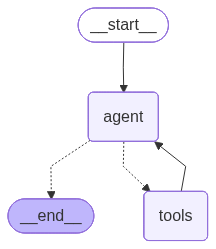

In [10]:
from IPython.display import Image, display

gv = graph.get_graph()                          # the structure of the compiled graph
                                   # show it in a Jupyter cell
display(Image(gv.draw_mermaid_png())) 
# gv.draw_ascii()


### Tracing the graph to LangSmith

[LangSmith](https://smith.langchain.com) is LangChain's observability platform. It
records every run as a **trace**: each node, each model call, each tool call — with
inputs, outputs, latency, and token counts laid out as a tree.

The best part: it's **automatic**. Set two environment variables and the graph above
traces itself — *no change to the graph code*. (Your `LANGSMITH_API_KEY` was already
loaded from `.env` in §0.)

In [11]:
import os
# the API key is already loaded from .env (§0) — just turn tracing on.
os.environ["LANGSMITH_TRACING"]  = "true"          # (older alias: LANGCHAIN_TRACING_V2)
os.environ["LANGSMITH_ENDPOINT"] = "https://eu.api.smith.langchain.com"  # EU workspace (omit/remove for US)
os.environ["LANGSMITH_PROJECT"]  = "agent-loop-demo"

print("LangSmith tracing ON · endpoint:", os.environ["LANGSMITH_ENDPOINT"])
print("  project:", os.environ["LANGSMITH_PROJECT"], "· key loaded:", bool(os.environ.get("LANGSMITH_API_KEY")))

LangSmith tracing ON · endpoint: https://eu.api.smith.langchain.com
  project: agent-loop-demo · key loaded: True


In [12]:
from langchain_core.tracers.context import tracing_v2_enabled

# Re-run the SAME compiled graph from §5 — now every step is recorded in LangSmith.
with tracing_v2_enabled(project_name="agent-loop-demo") as cb:
    result = graph.invoke({"messages": [{"role": "user",
        "content": "What's the weather where the next Summer Olympics will be held?"}]})

print(result["messages"][-1].content)
try:
    print("\n🔗 Open the full trace in LangSmith:\n  ", cb.get_run_url())
except Exception as e:
    print("\n(trace URL unavailable:", type(e).__name__,
          "— the run still traced; open it in the LangSmith UI under 'agent-loop-demo')")

The next Summer Olympics will be held in **Los Angeles, USA** (in 2028). The current weather there is **27°C and sunny**. ☀️

🔗 Open the full trace in LangSmith:
   https://eu.smith.langchain.com/o/0fa5a77a-5637-4bf5-bc49-d04d43031b69/projects/p/6227b836-144f-41f0-96f1-1364533e3e13/r/019eab67-3246-7b80-833c-9625ba76331b?poll=true


## 6. ...or just the one-liner — and swap the provider

`create_agent` ships the entire loop behind one call. It's the **same function**
from §4 — and the modern name for what LangGraph used to call
`langgraph.prebuilt.create_react_agent` (now deprecated). Here its job is to make
one point: the agent is **provider-agnostic**, so switching Claude → GPT is a
**one-line change** — the whole §3 comparison table collapses to this.

In [35]:
from langchain.agents import create_agent
from langchain_anthropic import ChatAnthropic
from langchain_openai import ChatOpenAI

lc_tools = [tool(get_weather), tool(calculator), tool(web_search)]
question = {"messages": [{"role": "user",
            "content": "Weather where the next Summer Olympics will be held?"}]}

agent = create_agent(ChatAnthropic(model=ANTHROPIC_MODEL), lc_tools)
print("── Claude ──")
print(agent.invoke(question)["messages"][-1].content)

agent = create_agent(ChatOpenAI(model=OPENAI_MODEL), lc_tools)   # ← only line that changes
print("\n── GPT ──")
print(agent.invoke(question)["messages"][-1].content)

── Claude ──
The next Summer Olympics will be held in **Los Angeles, USA (2028)**.

The current weather there is **27°C and sunny** — fitting for an Olympic host city! ☀️

── GPT ──
The current weather in Paris, where the next Summer Olympics will be held, is 18°C with light rain.


## 7. In practice — a good error message vs a bad one

The agent-computer interface — your tools — is the surface the model is *most*
sensitive to. To show it, the failure has to be something the model **can't** fix
from its own knowledge, so the *only* path to recovery is whatever the error says.

(A typo like "Prais"→"Paris" is a poor test: the model corrects that from world
knowledge no matter what the error says — so the error's wording doesn't matter.)
Instead we use a tool with **opaque order IDs the model cannot guess**. With a
*readable* error it recovers on the next turn; with a useless one it's stuck.

In [55]:
# A tool whose valid arguments are opaque IDs the model can't guess —
# so recovery depends entirely on what the error message tells it.
_ORDERS = {
    "ORD-8830": "Standing Desk ×1 — status: processing, ships Tuesday",
    "ORD-4471": "Wireless Keyboard ×2 — status: delivered",
}

def get_order_status(query: str) -> str:
    """Look up a customer's order. Pass the order ID, or the product the customer mentioned."""
    if query in _ORDERS:
        return _ORDERS[query]
    # GOOD error: names the valid IDs, so the model can retry correctly
    return (f"Error: '{query}' is not a valid order ID. Look up by exact order ID — "
            "e.g. ORD-8830 (Standing Desk), ORD-4471 (Wireless Keyboard).")

# register it as a tool the agent can call
TOOL_FUNCS["get_order_status"] = get_order_status

if not any(t["name"] == "get_order_status" for t in TOOLS_ANTHROPIC):
    TOOLS_ANTHROPIC.append({
        "name": "get_order_status",
        "description": "Look up the status of a customer order.",
        "input_schema": {
            "type": "object",
            "properties": {"query": {"type": "string",
                "description": "Order ID, or the product the customer mentioned"}},
            "required": ["query"],
        },
    })

print("=== GOOD error (names the valid order IDs) ===")
run_agent_anthropic("Can you check the status of my standing desk order?")

=== GOOD error (names the valid order IDs) ===
🧑  Can you check the status of my standing desk order?
──────────────────────────────────────────────────────────────────────
🤖  I'll check the status of your standing desk order right now.
   🔧 turn 1: get_order_status({'query': 'standing desk'}) 
      ↩  Error: 'standing desk' is not a valid order ID. Look up by exact order ID — e.g. ORD-8830 (Standing Desk), ORD-4471 (Wireless Keyboard).
🤖  I found your standing desk order! Here's the status:

**Order ORD-8830 — Standing Desk**

Let me pull up the current status for you.
   🔧 turn 2: get_order_status({'query': 'ORD-8830'}) 
      ↩  Standing Desk ×1 — status: processing, ships Tuesday
🤖  Here's the status of your standing desk order:

**Order ORD-8830 — Standing Desk (×1)**
- **Status:** Processing
- **Ships:** Tuesday

Your desk is currently being processed and is scheduled to ship out on Tuesday. Is there anything else you'd like to know about this order?
────────────────────────────

"Here's the status of your standing desk order:\n\n**Order ORD-8830 — Standing Desk (×1)**\n- **Status:** Processing\n- **Ships:** Tuesday\n\nYour desk is currently being processed and is scheduled to ship out on Tuesday. Is there anything else you'd like to know about this order?"

In [56]:
# Same tool, useless error message. The model can't guess 'ORD-8830' from 'error 5',
# so it can't recover. max_turns caps the flailing (and shows the guard firing).
def _bad_get_order_status(query: str) -> str:
    if query in _ORDERS:
        return _ORDERS[query]
    return "error 5"

_orig = TOOL_FUNCS["get_order_status"]
TOOL_FUNCS["get_order_status"] = _bad_get_order_status
try:
    print("=== BAD error ('error 5') — model has nothing to recover with ===")
    run_agent_anthropic("Can you check the status of my standing desk order?", max_turns=4)
finally:
    TOOL_FUNCS["get_order_status"] = _orig   # restore the good tool

=== BAD error ('error 5') — model has nothing to recover with ===
🧑  Can you check the status of my standing desk order?
──────────────────────────────────────────────────────────────────────
🤖  I'd be happy to help you check on your standing desk order!
   🔧 turn 1: get_order_status({'query': 'standing desk'}) 
      ↩  error 5
🤖  It looks like I'm running into a temporary error while trying to look up your standing desk order. Let me try that again for you.
   🔧 turn 2: get_order_status({'query': 'standing desk'}) 
      ↩  error 5
🤖  I'm sorry about this — I'm getting a system error when trying to look up your standing desk order, even after retrying. The order lookup tool seems to be temporarily unavailable.

A couple of things that might help:

1. **Do you have your Order ID?** If you can share it, I'll try the lookup again with that specific number, which sometimes works better than a product name.
2. **Try again shortly** — this appears to be a temporary glitch, so the system ma

## Takeaways

- Every stack ran the **same loop** — call → tool request → execute → feed back → repeat.
- The **tools were local and deterministic**; the only network call was the LLM,
  so the trajectory *is* the agent's reasoning made visible.
- Anthropic vs OpenAI differ only in **field names**; LangGraph hides the loop
  entirely and makes the provider swappable — but the tool catalog, the prompt,
  and the error messages are still **yours to design**.
- A good error message is a prompt: it's the difference between an agent that
  recovers and one that spins.

**Where next:** wrap this loop with memory, multiple agents, evaluation of the
*trajectory* (not just the final answer), and safety guardrails.

In [ ]:
# to validate the model is actually calling the web_search tool, 
# we can give it a fact only discoverable via that tool. 
# The system prompt instructs the model to always use web_search for real-world facts, 
# so if it answers correctly, we know it used the tool and got the fact from there — not from its own 
# (potentially outdated) training data.
SYS = ("Use web_search to look up any real-world fact (events, places, dates) "
        "before answering — do not rely on your own memory for current facts.")

agent = create_agent(ChatOpenAI(model=OPENAI_MODEL), lc_tools, system_prompt=SYS)
